# Basics of Probability
a. Tossing a coin 10,000 times and calculating the experimental probability of heads and tails.

In [1]:
import random

In [2]:
n_tosses = 10000

tosses = random.choices(['Heads', 'Tails'], k=n_tosses)

heads_count = tosses.count('Heads')
tails_count = n_tosses - heads_count

prob_heads = heads_count / n_tosses
prob_tails = tails_count / n_tosses

print(f"Total tosses: {n_tosses}")
print(f"Number of Heads: {heads_count} (Experimental Probability: {prob_heads:.4f})")
print(f"Number of Tails: {tails_count} (Experimental Probability: {prob_tails:.4f})")

Total tosses: 10000
Number of Heads: 5069 (Experimental Probability: 0.5069)
Number of Tails: 4931 (Experimental Probability: 0.4931)


- import random module to simulate random events
- n_tosses define how many times we want flip the coin
- tosses is list of n_tosses of "Head" or "Tails"
- heads_count count number of "Head" in tosses
- tails_count count number of "Tails" in tosses
- prob_head calulate probability of head
- prob_tails calulate probability of tails


further print the output

b. Rolling two dice and computing the probability of getting a sum of 7.  
Steps 
 
    a. Use Python's random module for simulations.  
    b. Implement loops for repeated trials.  
    c. Track outcomes and compute probabilities. 


In [3]:
import random

# Number of trials
n_trials = 10000
sum_7_count = 0

# b. Implement loops for repeated trials
for i in range(n_trials):
    # a. Use Python's random module for simulations
    dice_1 = random.randint(1, 6)
    dice_2 = random.randint(1, 6)
    
    # c. Track outcomes
    if dice_1 + dice_2 == 7:
        sum_7_count += 1

# compute probabilities
prob_sum_7 = sum_7_count / n_trials

print(f"Total trials: {n_trials}")
print(f"Number of times sum is 7: {sum_7_count}")
print(f"Experimental Probability: {prob_sum_7:.4f}")
print(f"Theoretical Probability (1/6): {1/6:.4f}")


Total trials: 10000
Number of times sum is 7: 1662
Experimental Probability: 0.1662
Theoretical Probability (1/6): 0.1667


- import random module for random die number.
- n_trails store number of trails.
- sum_7_count store sum of 7 of two dice
- for loop run for all trails
- if statement check if sum of both dice is 7 if true then increment by sum_7_count by 1
- prob_sum_7 calculate probability of sum of 7
- print output

# Conditional Probability and Bayes' Theorem
A bag contains 5 red, 7 green, and 8 blue balls. A ball is drawn randomly, its color noted, and it is put back into the bag. If this process is repeated 1000 times, write a Python program to estimate:  
a. The probability of drawing a red ball given that the previous ball was blue.  
b. Verify Bayes' theorem with the simulation results. 

In [4]:
import random

bag = ['Red'] * 5 + ['Green'] * 7 + ['Blue'] * 8

n_draws = 1000
draws = random.choices(bag, k=n_draws)

event_A_count = 0        
event_B_count = 0        
event_A_and_B_count = 0  

for i in range(1, n_draws):
    current = draws[i]
    previous = draws[i-1]
    
    if current == 'Red':
        event_A_count += 1
        
    if previous == 'Blue':
        event_B_count += 1
        
    if previous == 'Blue' and current == 'Red':
        event_A_and_B_count += 1


total_pairs = n_draws - 1

p_A = event_A_count / total_pairs
p_B = event_B_count / total_pairs


p_A_given_B = event_A_and_B_count / event_B_count if event_B_count > 0 else 0

p_B_given_A = event_A_and_B_count / event_A_count if event_A_count > 0 else 0

bayes_estimate = (p_B_given_A * p_A) / p_B if p_B > 0 else 0


print(f"Total simulated sequences (pairs of draws): {total_pairs}\n")

print(f"a. Estimated P(Current=Red | Previous=Blue): {p_A_given_B:.4f}\n")

print(f"b. Verifying Bayes' theorem:")
print(f"   P(Previous=Blue | Current=Red) = {p_B_given_A:.4f}")
print(f"   P(Current=Red) = {p_A:.4f}")
print(f"   P(Previous=Blue) = {p_B:.4f}")
print(f"   Bayes' Formula = [{p_B_given_A:.4f} * {p_A:.4f}] / {p_B:.4f} = {bayes_estimate:.4f}")

if abs(p_A_given_B - bayes_estimate) < 1e-6:
    print("\n✓ Bayes' theorem is verified successfully using the simulation results!")
else:
    print("\nDiscrepancy found.")


Total simulated sequences (pairs of draws): 999

a. Estimated P(Current=Red | Previous=Blue): 0.2228

b. Verifying Bayes' theorem:
   P(Previous=Blue | Current=Red) = 0.3308
   P(Current=Red) = 0.2603
   P(Previous=Blue) = 0.3864
   Bayes' Formula = [0.3308 * 0.2603] / 0.3864 = 0.2228

✓ Bayes' theorem is verified successfully using the simulation results!


- **Define the bag content:** Create a list `bag` containing 5 'Red', 7 'Green', and 8 'Blue' balls using list repetition.
- **Set number of draws:** Define `n_draws` as 1000.
- **Simulate draws:** Use `random.choices(bag, k=n_draws)` to simulate drawing 1000 balls with replacement.
- **Initialize event counters:** Set `event_A_count` (Current is Red), `event_B_count` (Previous was Blue), and `event_A_and_B_count` (Previous was Blue AND Current is Red) to 0.
- **Iterate through draws:** Loop from the second draw (index 1) to the end to compare current and previous draws.
- **Update counters:** Inside the loop, increment the respective counters if the conditions for Event A, Event B, or both are met.
- **Calculate total pairs:** Set `total_pairs` to `n_draws - 1` (since the first draw has no previous draw).
- **Calculate base probabilities:** Compute `p_A` (Probability of Red) and `p_B` (Probability of Blue) by dividing their counts by `total_pairs`.
- **Estimate Conditional Probability (Part a):** Calculate `P(Red | Previous was Blue)` as `event_A_and_B_count / event_B_count`.
- **Verify Bayes' Theorem (Part b):**
  - Calculate `P(Previous was Blue | Red)` as `event_A_and_B_count / event_A_count`.
  - Apply Bayes' formula: `[P(B|A) * P(A)] / P(B)`.
- **Print output:** Display the calculated probabilities and check if the estimated conditional probability matches the Bayes' theorem result.

# Random Variables and Discrete Probability
Generate a sample of size 1000 from a discrete random variable with the following distribution:  
  - P(X=1) = 0.25  
  - P(X=2) = 0.35  
  - P(X=3) = 0.4  
Compute the empirical mean, variance, and standard deviation of the sample.


In [5]:
import math
import numpy

# Possible values and their probabilities
values = [1, 2, 3]
probabilities = [0.25, 0.35, 0.40]

# Generate sample of size 1000
sample = numpy.random.choice(values, p=probabilities, size=1000 )

# Calculate empirical mean
# mean = sum(sample) / len(sample)
mean = numpy.mean(sample)
# Calculate variance
# variance = sum((x - mean) ** 2 for x in sample) / len(sample)
variance =  numpy.var(sample)
# Calculate standard deviation
# std_dev = math.sqrt(variance)
std_dev = numpy.std(sample)

# Print results
print("Empirical Mean:", mean.round(2))
print("Empirical Variance:", variance.round(2))
print("Empirical Standard Deviation:", std_dev.round(2))

Empirical Mean: 2.16
Empirical Variance: 0.63
Empirical Standard Deviation: 0.79


- Import required libraries
- Define values of the random variable
- Define probabilities
- Generate a sample of size 1000
- Compute empirical mean
- Compute variance
- Compute standard deviation
- Print the results

# Continuous Random Variables


5. Simulate 2000 random samples from an exponential distribution with a mean of 5. Visualize the distribution using:  
  a. A histogram.  
  b. A probability density function (PDF) overlay.


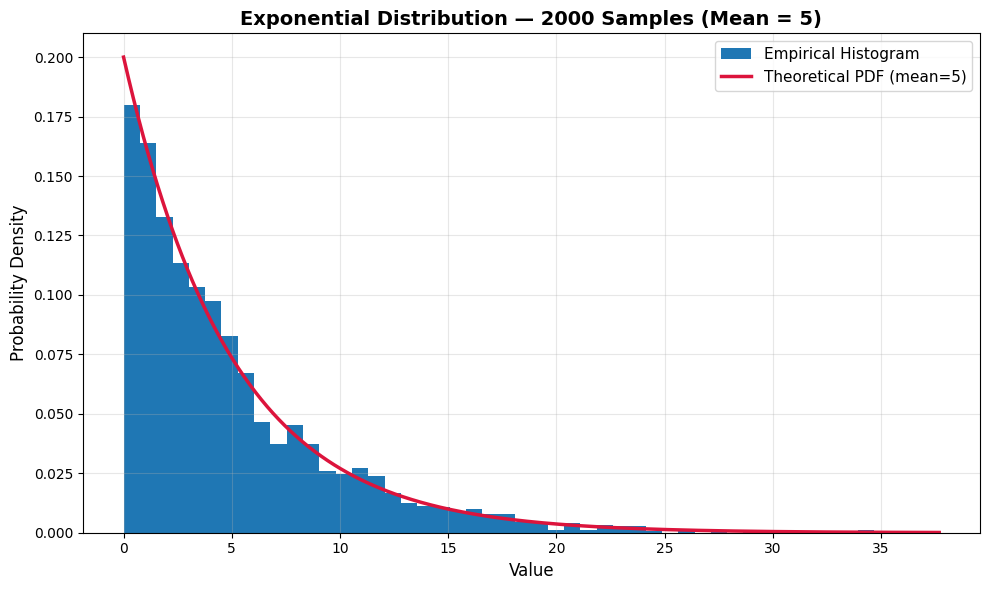

======= Sample Statistics =======
Mean              : 5.0310  (Theoretical: 5)
Variance          : 24.8948  (Theoretical: 25)
Std Deviation     : 4.9895  (Theoretical: 5)
Min               : 0.0009
Max               : 37.6937


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 2000 samples from exponential distribution with mean = 5
mean = 5
scale = mean
samples = np.random.exponential(scale=scale, size=2000)

# ===== Manual PDF Calculation (no scipy) =====
# Formula: f(x) = (1/scale) * e^(-x/scale)
x = np.linspace(0, max(samples), 1000)
pdf = (1 / scale) * np.exp(-x / scale)

# ===== Plot =====
fig, ax = plt.subplots(figsize=(10, 6))

# a. Histogram
ax.hist(samples, bins=50, density=True, label='Empirical Histogram')

# b. PDF Overlay (manual)
ax.plot(x, pdf, color='crimson', linewidth=2.5,
        label=f'Theoretical PDF (mean={mean})')

# Labels & formatting
ax.set_title('Exponential Distribution — 2000 Samples (Mean = 5)', fontsize=14, fontweight='bold')
ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exponential_distribution.png', dpi=150)
plt.show()

# ===== Statistics =====
print("======= Sample Statistics =======")
print(f"Mean              : {np.mean(samples):.4f}  (Theoretical: {mean})")
print(f"Variance          : {np.var(samples):.4f}  (Theoretical: {mean**2})")
print(f"Std Deviation     : {np.std(samples):.4f}  (Theoretical: {mean})")
print(f"Min               : {np.min(samples):.4f}")
print(f"Max               : {np.max(samples):.4f}")



# Central Limit Theorem


6. Simulate the Central Limit Theorem by following these steps  
  a. Generate 10,000 random numbers from a uniform distribution.  
  b. Draw 1000 samples of size n = 30.  
  c. Calculate and visualize the distribution of sample means.


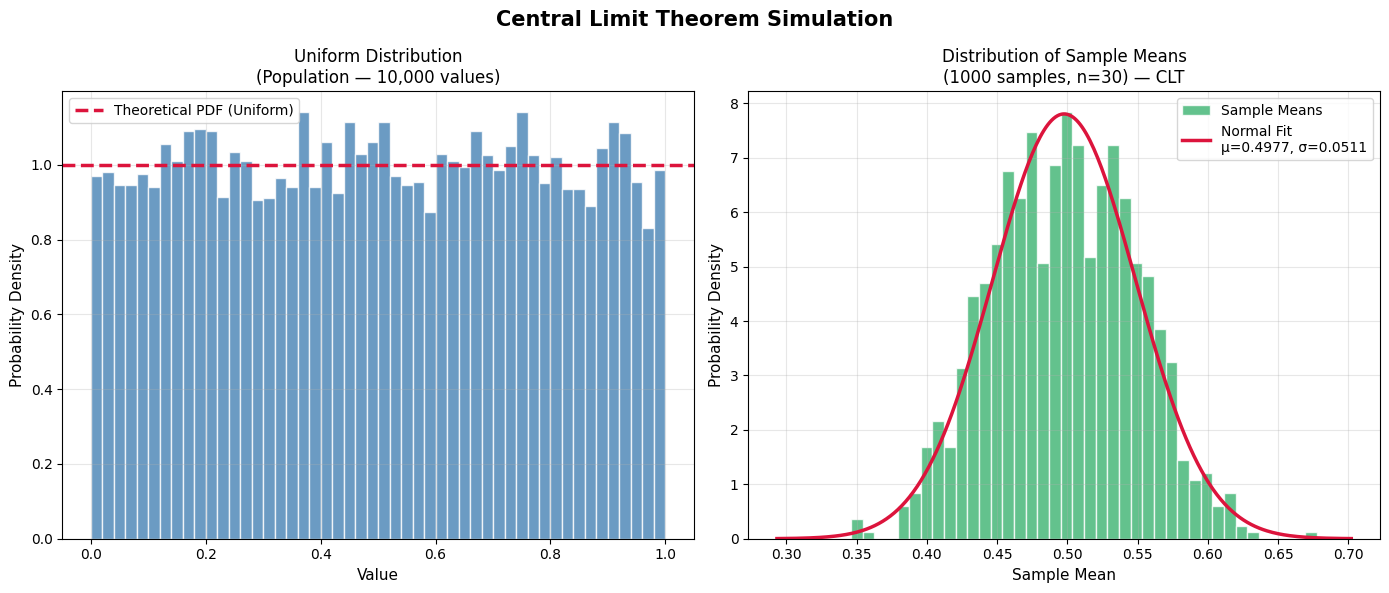

========= Population (Uniform) =========
Theoretical Mean      : 0.5000
Theoretical Std Dev   : 0.2887
Empirical Mean        : 0.5000
Empirical Std Dev     : 0.2870

======== Sample Means (CLT) =============
Mean of Sample Means  : 0.4977  (≈ 0.5)
Std of Sample Means   : 0.0511  (≈ 0.0527 = σ/√n)


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ── a. Generate 10,000 random numbers from Uniform Distribution ──
population = np.random.uniform(low=0, high=1, size=10_000)

# ── b. Draw 1000 samples of size n=30 & calculate sample means ──
n_samples = 1000
sample_size = 30

sample_means = [
    np.mean(np.random.choice(population, size=sample_size, replace=False))
    for _ in range(n_samples)
]
sample_means = np.array(sample_means)

# ── Manual Normal PDF (no scipy) ──
# Formula: f(x) = (1 / σ√2π) * e^(-(x-μ)² / 2σ²)
mu    = np.mean(sample_means)
sigma = np.std(sample_means)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
normal_pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# ── c. Visualize both distributions ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Central Limit Theorem Simulation', fontsize=15, fontweight='bold')

# ── Plot 1: Uniform Distribution (Population) ──
axes[0].hist(population, bins=50, density=True,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axhline(y=1.0, color='crimson', linewidth=2.5,
                linestyle='--', label='Theoretical PDF (Uniform)')
axes[0].set_title('Uniform Distribution\n(Population — 10,000 values)', fontsize=12)
axes[0].set_xlabel('Value', fontsize=11)
axes[0].set_ylabel('Probability Density', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Distribution of Sample Means (CLT) ──
axes[1].hist(sample_means, bins=40, density=True,
             color='mediumseagreen', edgecolor='white', alpha=0.8,
             label='Sample Means')

# Overlay manually computed Normal PDF
axes[1].plot(x, normal_pdf, color='crimson', linewidth=2.5,
             label=f'Normal Fit\nμ={mu:.4f}, σ={sigma:.4f}')

axes[1].set_title('Distribution of Sample Means\n(1000 samples, n=30) — CLT', fontsize=12)
axes[1].set_xlabel('Sample Mean', fontsize=11)
axes[1].set_ylabel('Probability Density', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('central_limit_theorem.png', dpi=150)
plt.show()

# ── Print Statistics ──
print("========= Population (Uniform) =========")
print(f"Theoretical Mean      : 0.5000")
print(f"Theoretical Std Dev   : {(1/12)**0.5:.4f}")
print(f"Empirical Mean        : {np.mean(population):.4f}")
print(f"Empirical Std Dev     : {np.std(population):.4f}")

print("\n======== Sample Means (CLT) =============")
print(f"Mean of Sample Means  : {np.mean(sample_means):.4f}  (≈ 0.5)")
print(f"Std of Sample Means   : {np.std(sample_means):.4f}  (≈ {(1/12)**0.5 / 30**0.5:.4f} = σ/√n)")